In [1]:
# Force the notebook to download the data from Nathaniel Miller's public GitHub repository at launch
!wget https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0198AbuNuwas.txt
!wget https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0211AbuAtahiya.txt

--2026-06-17 14:46:38--  https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0198AbuNuwas.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 618453 (604K) [text/plain]
Saving to: ‘0198AbuNuwas.txt.1’

0198AbuNuwas.txt.1  100%[===================>] 603.96K  --.-KB/s    in 0.05s   

2026-06-17 14:46:38 (12.4 MB/s) - ‘0198AbuNuwas.txt.1’ saved [618453/618453]

--2026-06-17 14:46:39--  https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0211AbuAtahiya.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting re

In [2]:
# 1. Install required rendering packages for Arabic right-to-left plotting
#!pip install arabic-reshaper python-bidi matplotlib seaborn -q
!pip install wordcloud arabic-reshaper python-bidi

# 2. Download raw text files directly from GitHub repository
import urllib.request
import os

base_url = "https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/"
files = ["0198AbuNuwas.txt", "0211AbuAtahiya.txt"]

for f in files:
    try:
        urllib.request.urlretrieve(base_url + f, f)
        print(f"Successfully cached file locally: {f}")
    except Exception as e:
        print(f"Error downloading {f}. Check your repository visibility and URL structure. Error: {e}")

Successfully cached file locally: 0198AbuNuwas.txt
Successfully cached file locally: 0211AbuAtahiya.txt


In [16]:
import os
import re
from collections import Counter

# Minimal Arabic stop words -- you can add to this list. After completing the
# rest of the cells try to add one of the words from the frequency distribution
# and see what happens.
AR_STOP_WORDS = set([
    "من", "في", "على", "إلى", "عن", "مع", "هذا", "هذه", "التي", "الذي",
    "ان", "أن", "لا", "ما", "يا", "و", "ف", "ب", "ل", "ثم", "أو", "كان", "كانت",
    "البحر", "إذا", "تام", "لم", "ولا", "حتى", "له", "كل", "قد", "إن", "به",
    "لي", "إلا", "بها", "لها", "منه", "غير", "طويل", "فيه", "ذا", "وما",
    "بسيط", "بين", "مجزوء", "وقد", 'قلت', "لو", "فما", "وإن", "لو", "لما",
    "فقلت", "منها", "يوم", "ليس", "كنت", "سريع", "كأن", "بعد", "وافر", "المرء",
    "فيها", "حين", "ال", "أنت","فإن", "مثل", "عليه", "ألا", "ترى", "إذ", "ولم",
    "ومن", "قال", "عند", "كامل",  "وفي", "كما", "علي", "منسرح", "لك", "مني",
    "ذي", "ذاك", "منك", "كأنما", "لنا", "لقد", "وكل", "بما", "كم", "يوما",
    "فقد", "إليه", "رأيت", "فلا", "وأنت", "بي", "شيء", "هو", "خفيف", "وليس",
    "متى", "فإذا", "وإذا", "رجز", "عليك", "الرمل", "نفس", "تر", "إني",
    "أما", "عنه", "يكون", "ولو", "وكم", "كيف", "بك", "ولكن", "عنك", "لست",
    "أيها", "عما", "أيا", "فيما", "من", "لكل", "حيث", "قل", "عنها", "ولقد",
    "فلم", "إنما", "أي", "لمن", "أهل", "منهم", "أنا", "نحن", "ذو", "فيا",
    "هل", "هي", "وهو", "غدا", "جميعا", "فأنت", "يرى", "مما", "شيئا",
    "ليت", "فقال", "كأنك", "أصبحت", "أراك", "دون", "فإني", "عندي",
    "ولست", "أين", "فليس", "بينهم", "أبا", "ممن", "بد", "رمل", "عليها",
    "علينا", "فيك", "وأي", "الكامل", "الهزج", "هزج", "ابن", "بني"
    ])


def parse_and_count(file_path, filter_stops=True):
    text_lines = []
    in_header = True

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find local file: {file_path}")

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            # FIX: Strip spaces to reliably catch the OpenITI header boundary
            if "#META#Header#End#" in line.replace(" ", ""):
                in_header = False
                continue
            if not in_header:
                text_lines.append(line)

    full_text = " ".join(text_lines)

    # Clean up OpenITI layout artifacts (e.g., page numbers, Latin tags)
    full_text = re.sub(r'PageV\d+P\d+\w*', '', full_text)
    full_text = re.sub(r'[A-Za-z0-9]+', '', full_text)

    # Strip tatweel/kashida and harakat (diacritics) for clean matching
    sanitized = re.sub(r'[\u064B-\u0652\u0640]', '', full_text)

    # Tokenize: explicitly capture clusters of Arabic script characters
    words = re.findall(r'[\u0621-\u064A]+', sanitized)

    if filter_stops:
            words = [w for w in words if w not in AR_STOP_WORDS and len(w) > 1]

    return Counter(words)

In [17]:
# This cell shows what we would have without metadata: the two poets' texts
# would form a single corpus in which we can't distinguish the two sets of vocabulary

# 1. Calculate individual distributions
nuwas_counts = parse_and_count("0198AbuNuwas.txt", filter_stops=True)
atah_counts = parse_and_count("0211AbuAtahiya.txt", filter_stops=True)

# 2. Combine the distributions using Counter addition
# This automatically sums the counts for overlapping words
combined_counts = nuwas_counts + atah_counts

# Define display slice
top_n_combined = 10

print(f"--- DYNAMIC COMBINED TOP {top_n_combined} WORDS (TOTAL CORPUS) ---")
for word, count in combined_counts.most_common(top_n_combined):
    print(f"Token: {word} | Total Count: {count}")

--- DYNAMIC COMBINED TOP 10 WORDS (TOTAL CORPUS) ---
Token: الله | Total Count: 217
Token: الناس | Total Count: 175
Token: الدنيا | Total Count: 118
Token: الدهر | Total Count: 93
Token: الموت | Total Count: 83
Token: الهوى | Total Count: 65
Token: قلبي | Total Count: 62
Token: الكأس | Total Count: 60
Token: الخمر | Total Count: 56
Token: نفسي | Total Count: 55


In [18]:
from collections import Counter

def merge_al_pairs(counts_dict):
    merged = Counter()
    merged_words = set()  # Track which bare words received counts from an 'ال' version

    for word, count in counts_dict.items():
        if word.startswith("ال"):
            bare_word = word[2:]  # Strip the 'ال'

            if bare_word in counts_dict:
                # Pair exists! Merge this count into the bare word
                merged[bare_word] += count
                merged_words.add(bare_word)
            else:
                # No bare version exists (like الله), keep it as is
                merged[word] += count
        else:
            # It's already a bare word, add its own count
            merged[word] += count

    # Re-add 'ال' only to the words that were actually merged
    final_counts = Counter()
    for word, count in merged.items():
        if word in merged_words:
            final_counts["ال" + word] = count
        else:
            final_counts[word] = count

    return final_counts

# Post-process your counts to merge pairs
nuwas_counts = merge_al_pairs(parse_and_count("0198AbuNuwas.txt", filter_stops=True))
atah_counts = merge_al_pairs(parse_and_count("0211AbuAtahiya.txt", filter_stops=True))

# Your printing logic stays exactly the same
top_n = 10

print(f"--- DYNAMIC TOP {top_n} WORDS: ABU NUWAS ---")
for word, count in nuwas_counts.most_common(top_n):
    print(f"Token: {word} | Count: {count}")

print(f"\n--- DYNAMIC TOP {top_n} WORDS: ABU AL-ATAHIYAH ---")
for word, count in atah_counts.most_common(top_n):
    print(f"Token: {word} | Count: {count}")

--- DYNAMIC TOP 10 WORDS: ABU NUWAS ---
Token: الله | Count: 134
Token: الناس | Count: 107
Token: الهوى | Count: 87
Token: الكأس | Count: 84
Token: العين | Count: 77
Token: الخمر | Count: 72
Token: الحسن | Count: 66
Token: الدهر | Count: 66
Token: الحب | Count: 61
Token: الليل | Count: 60

--- DYNAMIC TOP 10 WORDS: ABU AL-ATAHIYAH ---
Token: الدنيا | Count: 108
Token: الموت | Count: 83
Token: الله | Count: 83
Token: الناس | Count: 75
Token: الدار | Count: 32
Token: الدهر | Count: 30
Token: لله | Count: 28
Token: الخير | Count: 21
Token: الأيام | Count: 20
Token: الفتى | Count: 19


In [19]:
def save_vocab_to_file(counts, filename):
    with open(filename, "w", encoding="utf-8") as f:
        # .most_common() without arguments yields every single vocabulary item sorted by frequency
        for word, count in counts.most_common():
            f.write(f"{word}: {count}\n")

# Generate individual files for each poet
save_vocab_to_file(nuwas_counts, "0198AbuNuwas_vocab.txt")
save_vocab_to_file(atah_counts, "0211AbuAtahiya_vocab.txt")

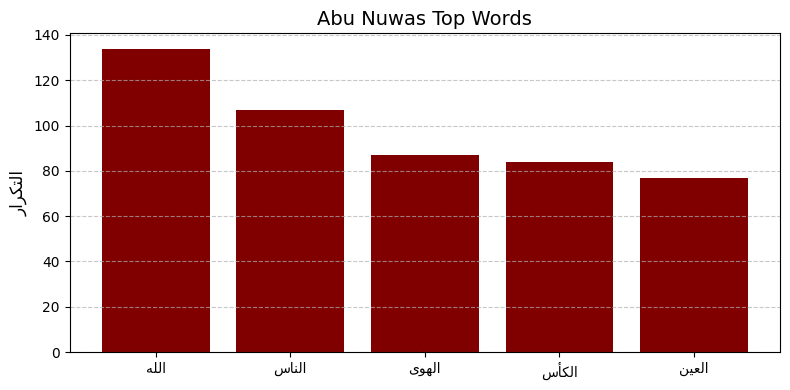

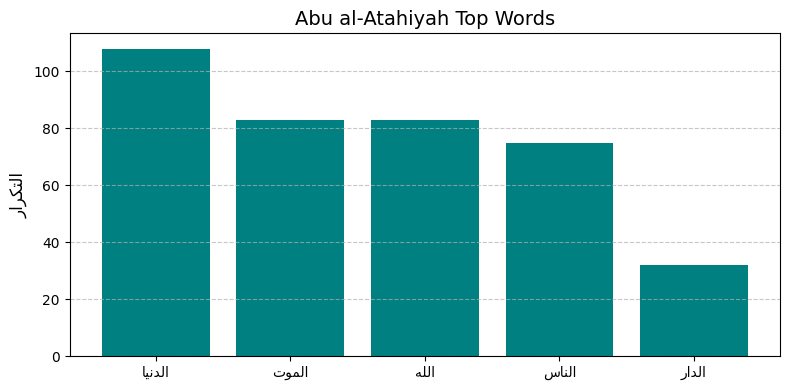

In [22]:
import matplotlib.pyplot as plt
from arabic_reshaper import ArabicReshaper

# Configure a reshaper instance that avoids font-breaking single-glyph ligatures
safe_arabic_config = {
    'delete_harakat': True,
    'support_ligatures': False
}
safe_reshaper = ArabicReshaper(configuration=safe_arabic_config)

def plot_top_words(word_counter, title_text="Top Words", color="steelblue"):
    top_5 = word_counter.most_common(5)
    if not top_5:
        print("No data available to plot. Ensure Cell 3 generated counts.")
        return

    words, counts = zip(*top_5)

    # Process the labels using our ligature-safe config
    reshaped_labels = [get_display(safe_reshaper.reshape(w)) for w in words]

    # Generate the bar chart
    plt.figure(figsize=(8, 4))
    plt.bar(reshaped_labels, counts, color=color)

    # Safely shape the chart typography
    plt.title(get_display(safe_reshaper.reshape(title_text)), fontsize=14)
    plt.ylabel(get_display(safe_reshaper.reshape("التكرار")), fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- THE EXECUTION CALLS ---
# These must be un-commented to actually trigger the visualization plots
plot_top_words(nuwas_counts, title_text="Abu Nuwas Top Words", color="maroon")
plot_top_words(atah_counts, title_text="Abu al-Atahiyah Top Words", color="teal")

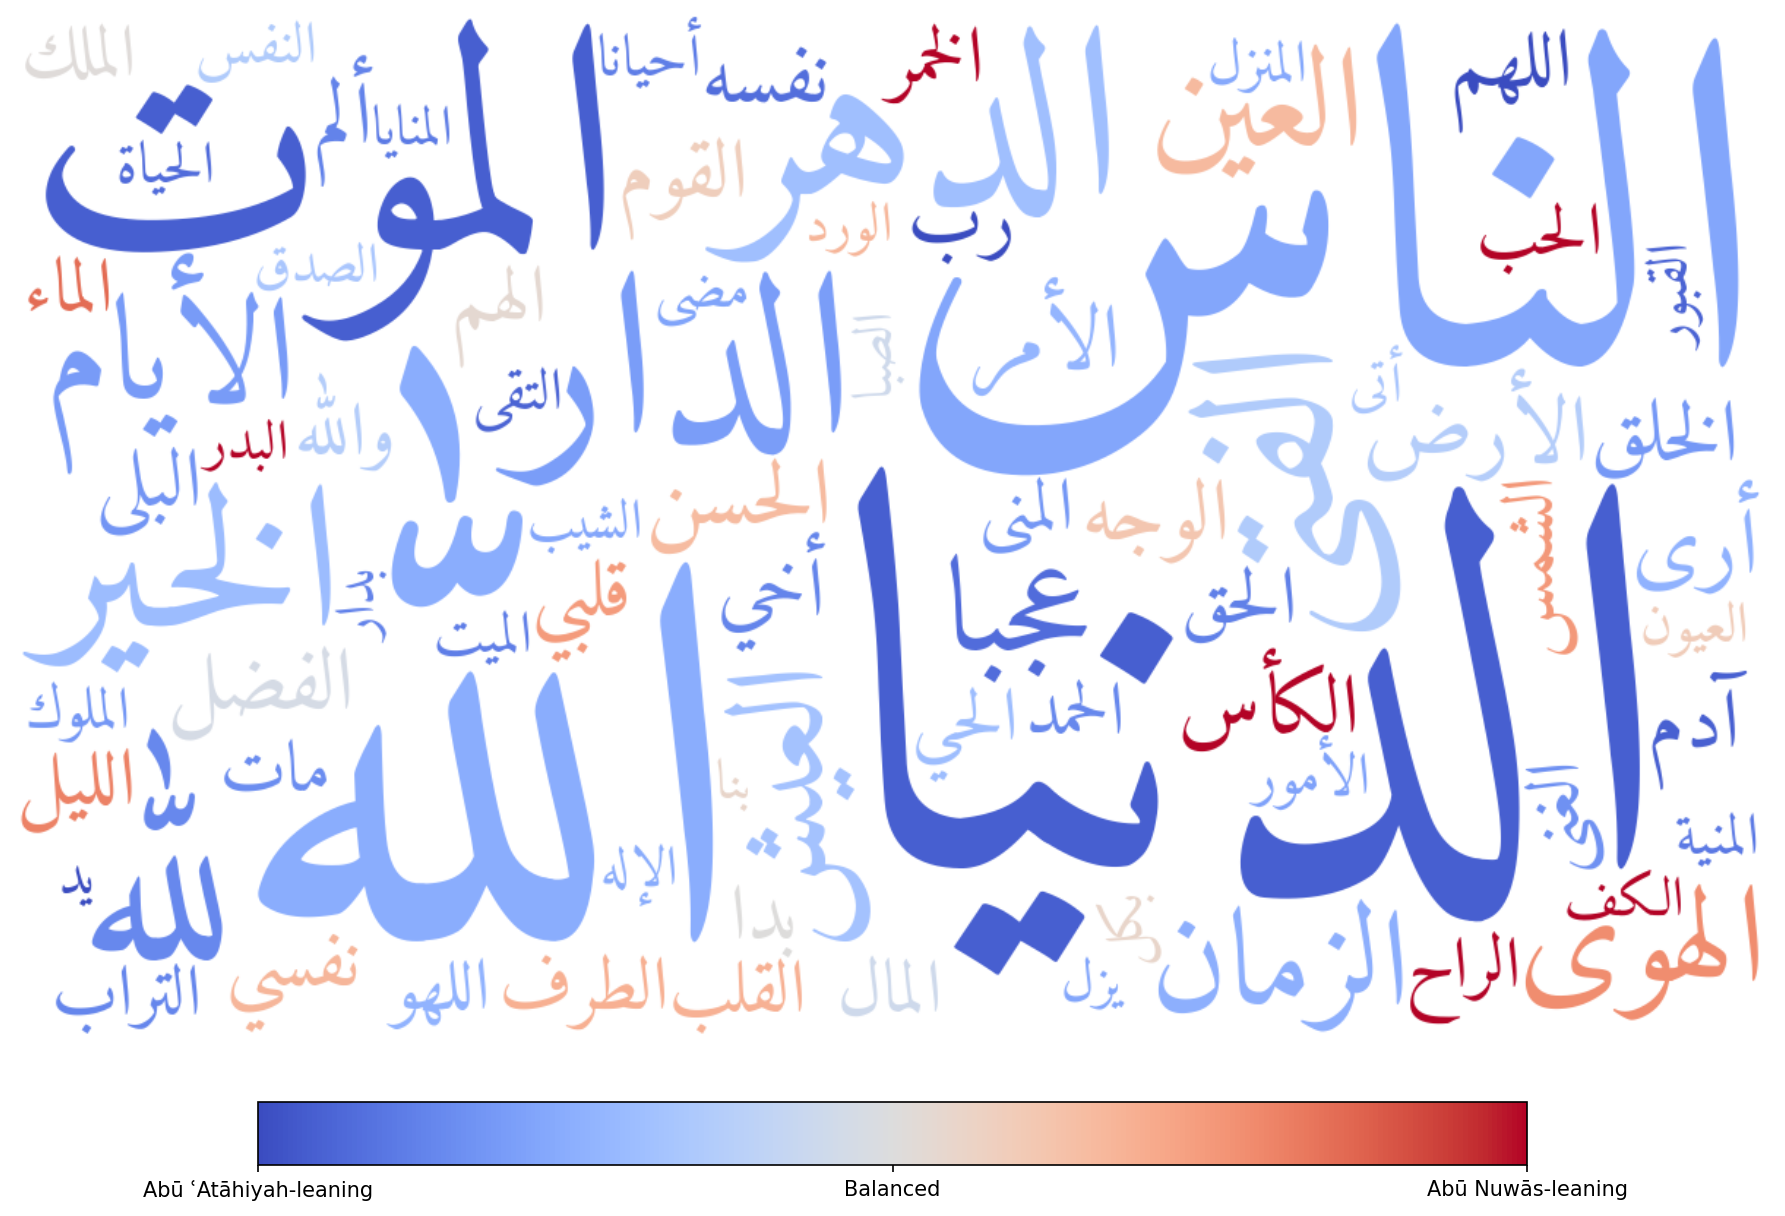

In [21]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from wordcloud import WordCloud
from arabic_reshaper import ArabicReshaper
from bidi.algorithm import get_display
from PIL import features

HAS_RAQM = features.check("raqm")

reshaper = ArabicReshaper({
    'delete_harakat': True,
    'support_ligatures': True,
    'delete_tatweel': True,
})

total_nuwas = sum(nuwas_counts.values())
total_atah = sum(atah_counts.values())

combined_frequencies = {}
word_lean = {}  # display_word -> lean score: -1 = pure Atah, +1 = pure Nuwas

for word in set(nuwas_counts.keys()) | set(atah_counts.keys()):
    freq_nuwas = nuwas_counts[word] / total_nuwas if total_nuwas > 0 else 0
    freq_atah = atah_counts[word] / total_atah if total_atah > 0 else 0

    if len(word.strip()) > 1:
        display_word = word if HAS_RAQM else get_display(reshaper.reshape(word))
        combined_frequencies[display_word] = freq_nuwas + freq_atah

        total = freq_nuwas + freq_atah
        word_lean[display_word] = (freq_nuwas - freq_atah) / total if total > 0 else 0

cmap = plt.cm.coolwarm  # blue end = Atah-leaning, red end = Nuwas-leaning

def lean_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    lean = word_lean.get(word, 0)
    rgba = cmap((lean + 1) / 2)
    r, g, b = (int(c * 255) for c in rgba[:3])
    return f"rgb({r}, {g}, {b})"

wc = WordCloud(
    font_path="Amiri-Regular.ttf",
    background_color="white",
    width=1200,
    height=700,
    max_words=80,
    prefer_horizontal=0.9,
    random_state=42,
    color_func=lean_color_func,
).generate_from_frequencies(combined_frequencies)

fig, ax = plt.subplots(figsize=(12, 9), dpi=150)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

norm = mcolors.Normalize(vmin=-1, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["Abū ʿAtāhiyah-leaning", "Balanced", "Abū Nuwās-leaning"])

plt.tight_layout()
plt.show()